In [10]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path("results/n2s_unet_bsd68_gaussian_002/output")

clean = np.load(output_dir / "clean.npy")
noisy = np.load(output_dir / "noisy.npy")
denoised = np.load(output_dir / "denoised.npy")
score = np.load(output_dir / "score.npy")

print(clean.shape, noisy.shape, denoised.shape, score.shape)

(64, 1, 128, 128) (64, 1, 128, 128) (64, 1, 128, 128) (64, 1, 128, 128)


In [11]:
# 이미지 shape로 복원
image_shape=(128, 128)

def to_img(x, image_shape=image_shape):
    return x.reshape(-1, *image_shape)

clean_img = to_img(clean)
noisy_img = to_img(noisy)
denoised_img = to_img(denoised)
score_img = to_img(score)

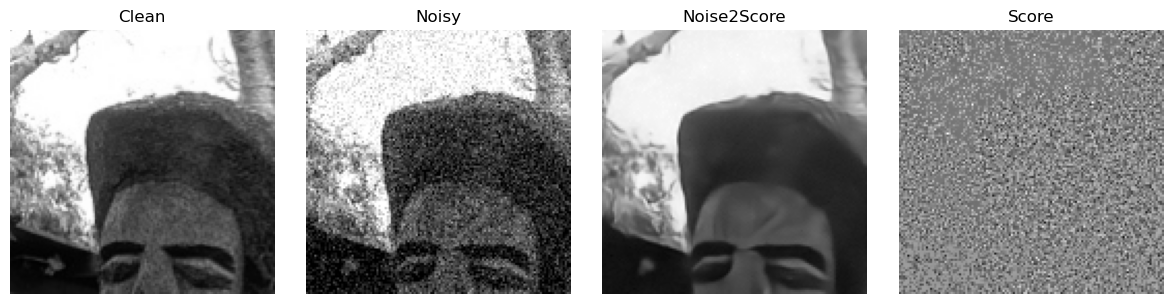

In [12]:
# 시각화

def show_triplet(idx=0):
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))

    axes[0].imshow(clean_img[idx], cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Clean")

    axes[1].imshow(noisy_img[idx], cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Noisy")

    axes[2].imshow(denoised_img[idx], cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("Noise2Score")

    axes[3].imshow(score_img[idx], cmap="gray")
    axes[3].set_title("Score")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_triplet(0)

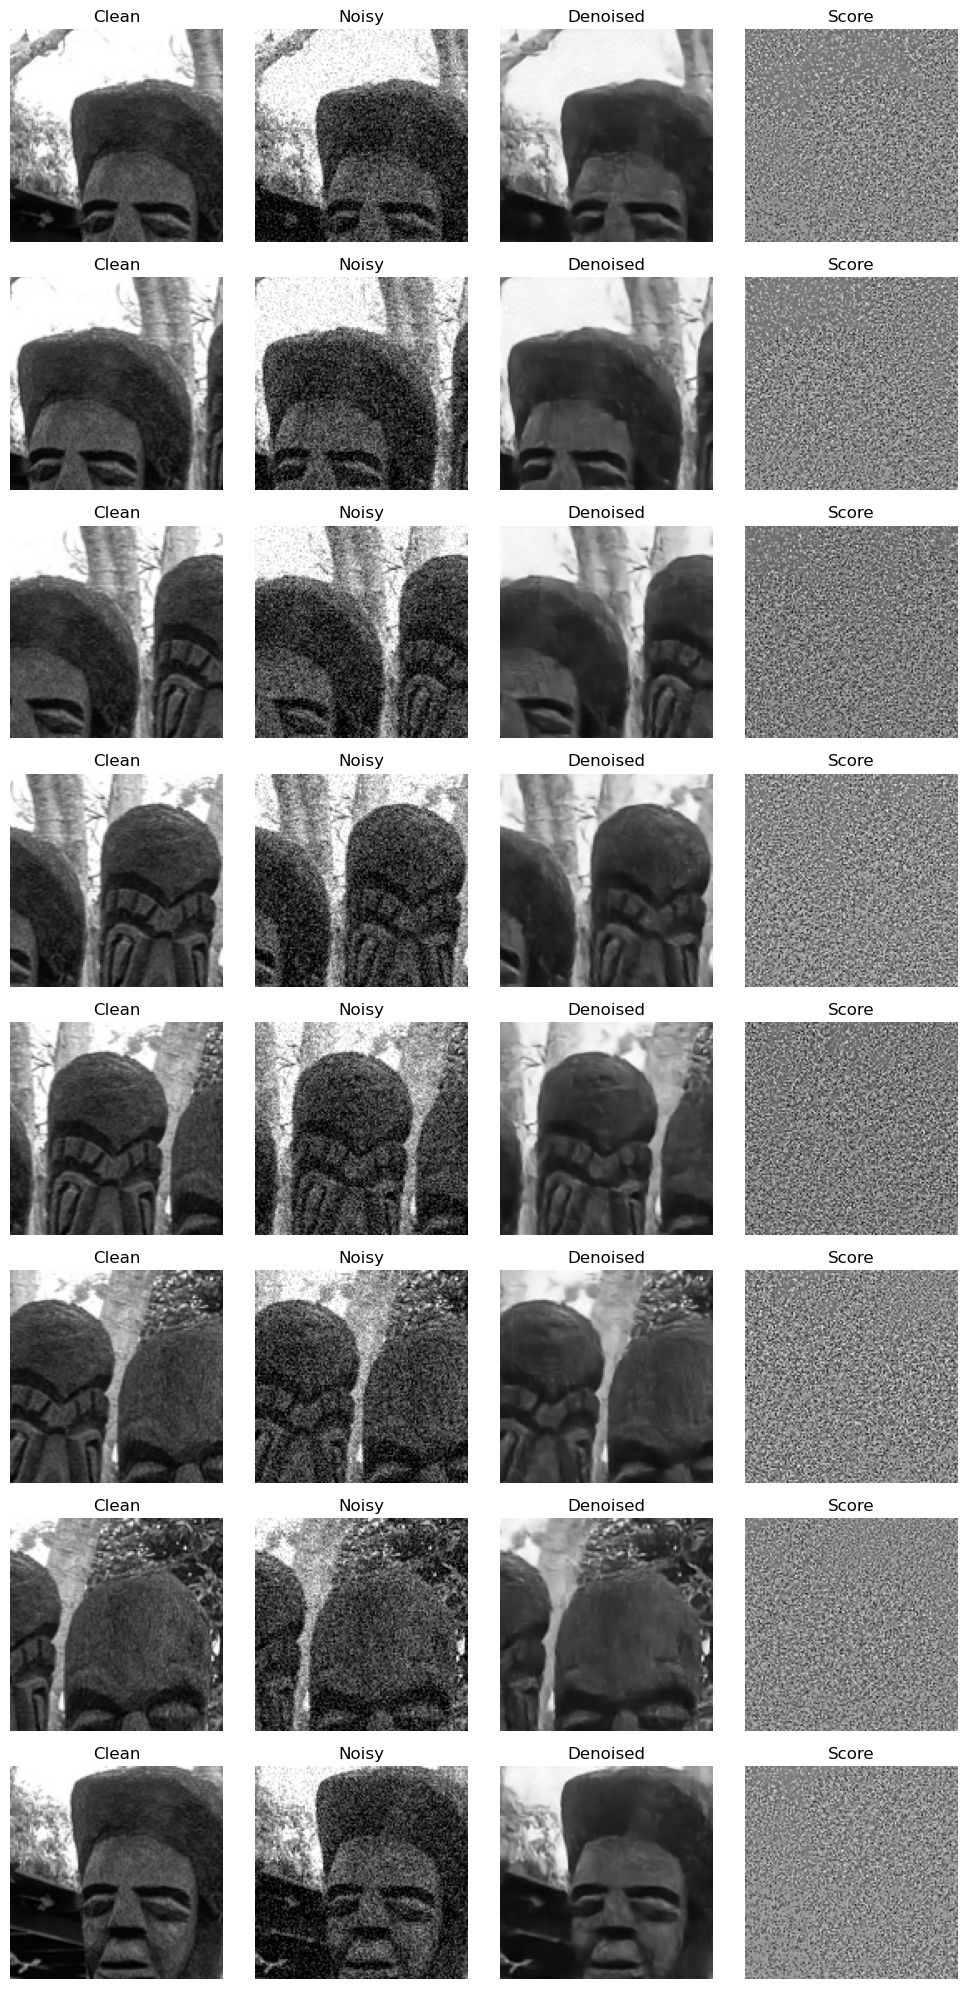

In [4]:
# 여러개 한번에 보기

def show_grid(n=8):
    fig, axes = plt.subplots(n, 4, figsize=(10, 2.5 * n))

    for i in range(n):
        axes[i, 0].imshow(clean_img[i], cmap="gray", vmin=0, vmax=1)
        axes[i, 0].set_title("Clean")

        axes[i, 1].imshow(noisy_img[i], cmap="gray", vmin=0, vmax=1)
        axes[i, 1].set_title("Noisy")

        axes[i, 2].imshow(denoised_img[i], cmap="gray", vmin=0, vmax=1)
        axes[i, 2].set_title("Denoised")

        axes[i, 3].imshow(score_img[i], cmap="gray")
        axes[i, 3].set_title("Score")

        for j in range(4):
            axes[i, j].axis("off")

    plt.tight_layout()
    plt.show()

show_grid(8)

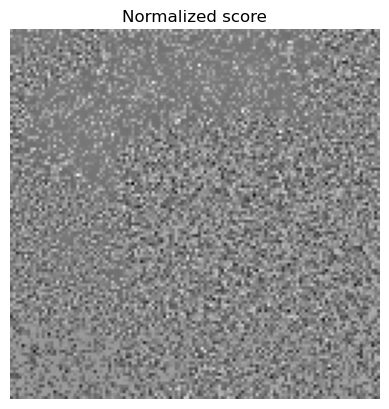

In [9]:
def normalize_for_view(x):
    x_min = x.min()
    x_max = x.max()
    return (x - x_min) / (x_max - x_min + 1e-8)

idx = 0

plt.imshow(normalize_for_view(score_img[idx]), cmap="gray")
plt.title("Normalized score")
plt.axis("off")
plt.show()